In [1]:
import sys
import pickle
from pathlib import Path

import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt

import config, data, models, train, evaluate

In [2]:
save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
metadata_dir = save_dir / "metadata"

subbasins = pd.read_parquet(metadata_dir / 'subbasins.parquet', columns=['site_id', 'uparea_km2', 'is_gauge', 'outlet_id'])
subbasins.index = subbasins.index.astype(str)

In [4]:
exp_root = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay")

exp_dirs = [p.parent for p in (exp_root).rglob('results/test_results.parquet')] # dirs with test_data.pkl
exp_dirs

[PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/era5_20251209_213752/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/swot_20251209_213937/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/swot_mse_20251209_213951/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/era5_mse_20251209_214016/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/era5_spq_20251209_214032/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/swot_spq_20251209_214052/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/swot_spq_mse_20251210_140925/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/era5_spq_mse_20251210_141040/results')]

In [54]:
exp_root =  Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/")
exp_dirs = [
    Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/era5_spq_mse_20251210_141040/results"),
    Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/swot_spq_mse_20251210_140925/results"),
    Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/swot_spq_mse_zstd_20251210_194133/results"),
]
target = 'discharge'

In [5]:
def calc_discharge(df, subs):
    uparea = subs['uparea_km2'] 
    mapped_uparea = df.index.get_level_values('subbasin').map(uparea)
    
    df[('pred', 'discharge')] = df[('pred','unit_discharge')] * mapped_uparea
    df[('obs', 'discharge')] = df[('obs','unit_discharge')] * mapped_uparea
    return df

In [56]:
fig_dir = exp_root / "_figures"
fig_dir.mkdir(exist_ok=True, parents=True)

from tqdm import tqdm
import evaluate

exps = []
for exp_dir in tqdm(exp_dirs):
    try:
        results = pd.read_parquet(exp_dir / 'test_results.parquet').dropna()

        if 'unit_discharge' in results['pred'].columns:
            results = calc_discharge(results, subbasins)

        bulk_m = evaluate.get_all_metrics(results)
        basin_m = evaluate.get_basin_metrics(results)

        exp_name = exp_dir.parent.stem 

        # with open(exp_dir / "test_metrics.pkl", 'rb') as f:
        #     bulk_m, basin_m = pickle.load(f)
        
        exps.append((exp_name, results, bulk_m, basin_m))
    except Exception as e:
        print(e)
        pass

exps = sorted(exps, key=lambda x: x[0])

100%|██████████| 3/3 [00:18<00:00,  6.26s/it]

[Errno 2] No such file or directory: '/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_no_decay/swot_spq_mse_zstd_20251210_194133/results/test_results.parquet'


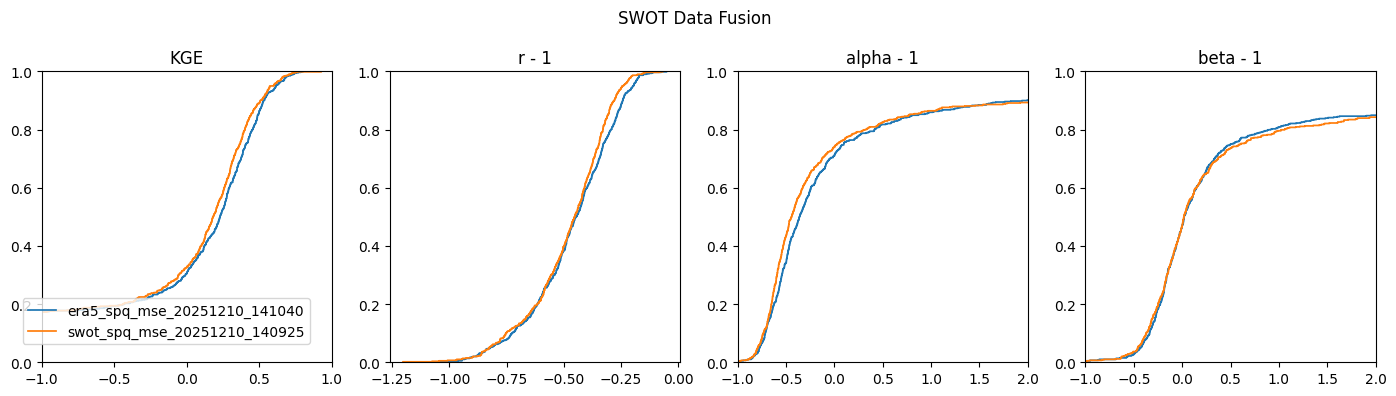

In [57]:
plt.close('all')

num_models = len(exps)

metric_names = {
    'KGE': 'KGE',
    'corr': 'r - 1',
    'alpha': 'alpha - 1',
    'beta': 'beta - 1'
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for ax, (name, title) in zip(axes, metric_names.items()):
    for exp_name, results, bulk_metrics, basin_metrics in exps:
        x = np.array(basin_metrics[target][name], dtype=float)
        
        if name in ['alpha', 'beta', 'corr']:
            x = x-1
        
        
        x = x[~np.isnan(x)]
        ax.ecdf(x, linewidth=1.25, label=exp_name)
    
    ax.set_title(f"{title}")

axes[0].set_xlim([-1, 1])
# axes[1].set_xlim([0, 1])
axes[2].set_xlim([-1, 2])
axes[3].set_xlim([-1, 2])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.23, 0.2))

# fig.subplots_adjust(left=0.1, right=0.95, bottom=0.2, top=0.95, wspace=0.3, hspace=0.4)
plt.suptitle('SWOT Data Fusion')
plt.tight_layout()
plt.show()

# fig.savefig(fig_dir / f"KGE_decomp.png", dpi=300)

Index(['ECCC-11AA025', 'USGS-06185500', 'USGS-06172310', 'USGS-06155500',
       'USGS-06154100', 'USGS-06140500', 'USGS-06135000', 'USGS-06329500',
       'USGS-06115200', 'USGS-06151500',
       ...
       'USGS-03292494', 'USGS-06918250', 'USGS-07261090', 'USGS-07260800',
       'USGS-07263115', 'USGS-06354050', 'USGS-06680500', 'USGS-03324095',
       'USGS-07026500', 'USGS-06767970'],
      dtype='object', name='subbasin', length=597)

In [30]:
subbasins

,uparea_km2,is_gauge,outlet_id
site_id,,,
23021321,209.123678,False,EAUF-A3750050
23021261,213.109547,False,EAUF-A3750050
23021244,291.030672,False,EAUF-A3750050
23021122,477.964586,False,EAUF-A3750050
23021112,394.295017,False,EAUF-A3750050
...,...,...,...
81003765,1613.152478,False,USGS-15908000
81001414,1473.949940,False,USGS-15908000
81001413,2751.705206,False,USGS-15908000


In [40]:
basin_mask = (subbasins['outlet_id'] == 'USGS-07374000')
basin_mask.sum()

8143

In [41]:
test_sub_mask = subbasins.index.isin(results.index.get_level_values('subbasin').unique())
test_sub_mask.sum()

597

In [61]:
8143*4

32572

In [44]:
import xarray as xr

basin_mask = (subbasins['outlet_id'] == 'USGS-07374000')
test_sub_mask = subbasins.index.isin(results.index.get_level_values('subbasin').unique())
basin_gauges = subbasins[basin_mask & test_sub_mask].index
basin_ds = xr.open_zarr("/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/USGS-07374000")
gauge_ds = basin_ds.sel(subbasin=basin_gauges, date=slice(start_date, end_date))


# ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
# has_swot_obs = ~np.isnan(ds['d_wse_river'].to_numpy())

In [45]:
gauge_swot_count = (~gauge_ds['d_wse_river'].to_dataframe().isna()).groupby('subbasin').apply(sum)

gauge_swot_count.sort_values(by='d_wse_river')

/tmp/ipykernel_2454930/809201948.py:1: FutureWarning: The provided callable <built-in function sum> is currently using np.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.sum instead.
  gauge_swot_count = (~gauge_ds['d_wse_river'].to_dataframe().isna()).groupby('subbasin').apply(sum)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,d_wse_river
subbasin,
USGS-06281000,0
USGS-06359500,0
USGS-06356500,0
USGS-06354050,0
USGS-06354000,0
...,...
USGS-03453500,44
USGS-06777495,45
USGS-06287800,47


0

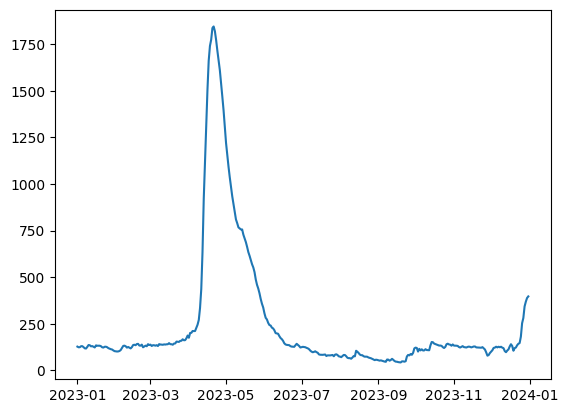

In [16]:
df = gauge_ds.sel(subbasin='USGS-05288500')['discharge'].to_dataframe()

plt.plot(df.index, df.discharge)

In [17]:
kge = exps[1][3][target]['KGE'].dropna().sort_values()

kge[kge>0]

USGS-06646000    0.001718
USGS-03415000    0.003273
USGS-06037100    0.003283
USGS-03318800    0.004934
USGS-06115200     0.00706
                   ...   
USGS-03331500    0.747955
USGS-03140500    0.778909
USGS-05288500    0.786657
USGS-03105500    0.792147
USGS-06289000    0.908877
Name: KGE, Length: 406, dtype: object

In [13]:
basin_id

'USGS-07374000'

3
era5_spq_mse_20251210_141040: -0.03
swot_spq_20251210_141236: 0.79


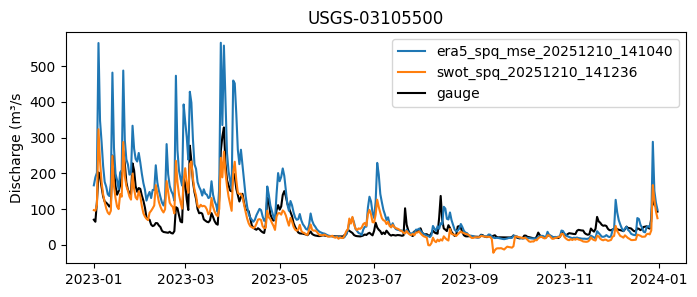

In [19]:
import xarray as xr

reach_id = 'USGS-03105500'
start_date = "2023-01-01"
end_date = "2023-12-31"
metric = 'KGE'

# Horrible hackishness
basin_id = subbasins.loc[reach_id]['outlet_id']
ds = xr.open_zarr(f"/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/{basin_id}")
ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
has_swot_obs = ~np.isnan(ds['d_wse_river'].to_numpy())

print(np.sum(has_swot_obs))

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

for exp_name, results, bulk_metrics, basin_metrics in exps: 
    xs = results.xs(reach_id, level='subbasin').sort_index()
    xs = xs.droplevel(0,0)
    xs = xs.loc[start_date:end_date]

    x = xs.index
    y = xs['pred'][target]
    # err = xs['pred']['discharge_std']
    plt.plot(x, y, label=exp_name)
    # plt.fill_between(x, y-err, y+err, alpha=0.3, facecolor=color, antialiased=True)
    
    print(f"{exp_name}: {basin_metrics.loc[reach_id][target][metric]:0.2f}")
    
ax.plot(xs.index, xs['obs'][target], color='black', zorder=0, label='gauge')

plt.legend()
plt.title(reach_id)
plt.ylabel("Discharge (m³/s")
plt.show()
fig.savefig(fig_dir / f"timeseries_{reach_id}.png", dpi=300)

In [20]:
kge = exps[1][3][target]['KGE'].dropna()
kge = kge[(kge>0)].sort_values()
kge = kge.sort_values(ascending=False)

kge

USGS-06289000    0.908877
USGS-03105500    0.792147
USGS-05288500    0.786657
USGS-03140500    0.778909
USGS-03331500    0.747955
                   ...   
USGS-06115200     0.00706
USGS-03318800    0.004934
USGS-06037100    0.003283
USGS-03415000    0.003273
USGS-06646000    0.001718
Name: KGE, Length: 406, dtype: object

In [46]:
gauge_swot_count = gauge_swot_count.sort_values(by='d_wse_river', ascending=False)

USGS-06041000
era5_spq_mse_20251210_141040: 0.29
swot_spq_20251210_141236: 0.20


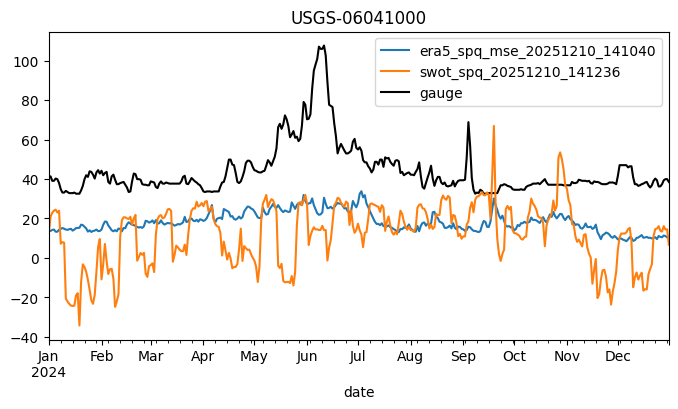

USGS-06040000
era5_spq_mse_20251210_141040: -0.95
swot_spq_20251210_141236: -0.32


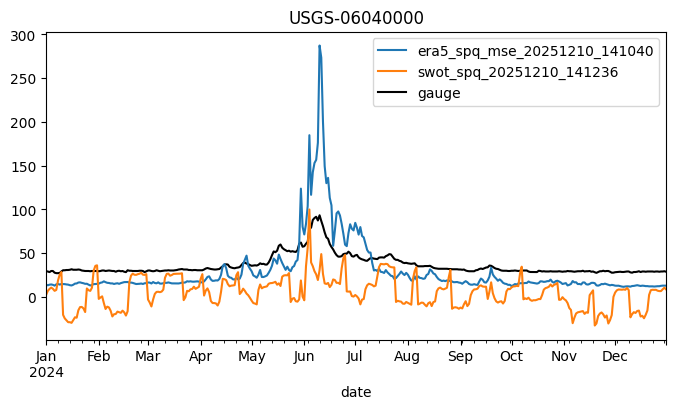

USGS-06287800
era5_spq_mse_20251210_141040: -2.61
swot_spq_20251210_141236: -1.64


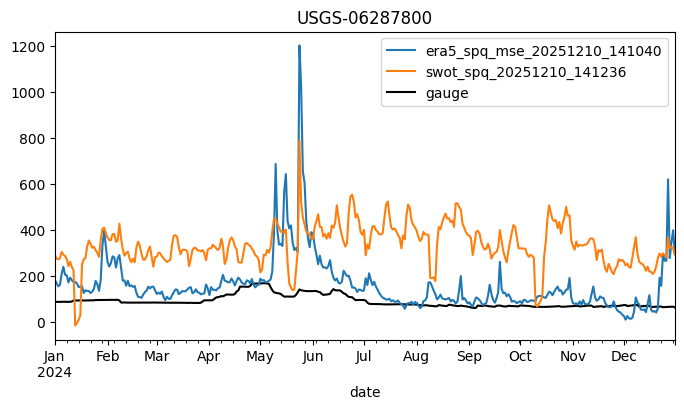

USGS-06777495
era5_spq_mse_20251210_141040: -2.36
swot_spq_20251210_141236: -1.53


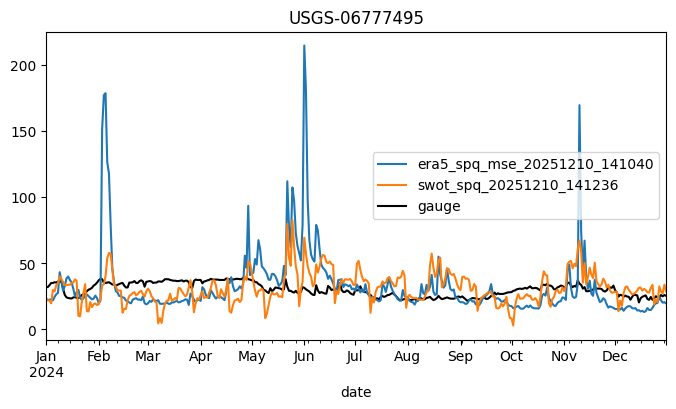

USGS-03453500
era5_spq_mse_20251210_141040: 0.28
swot_spq_20251210_141236: -0.16


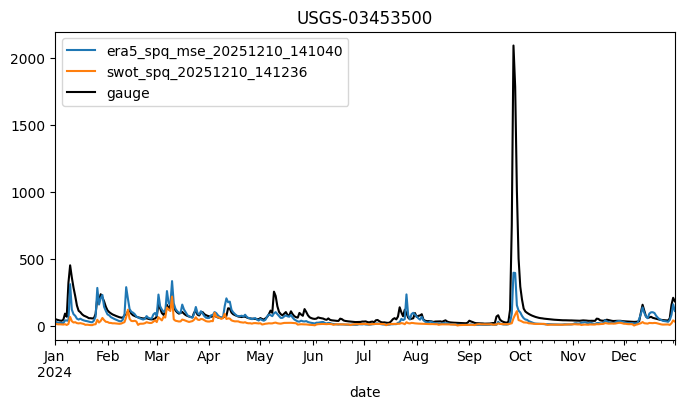

USGS-06759500
era5_spq_mse_20251210_141040: -2.58
swot_spq_20251210_141236: -5.48


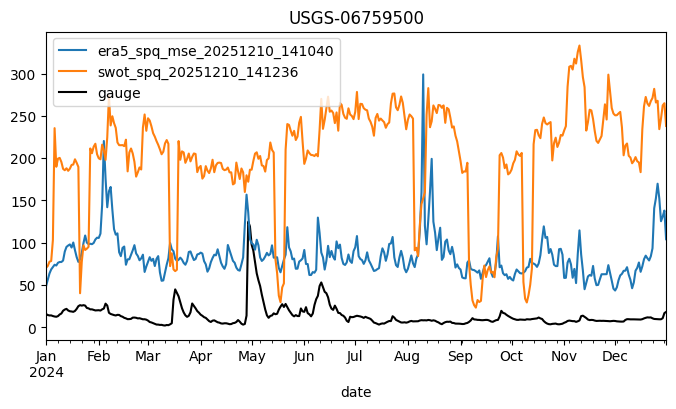

USGS-03294500
era5_spq_mse_20251210_141040: 0.52
swot_spq_20251210_141236: 0.22


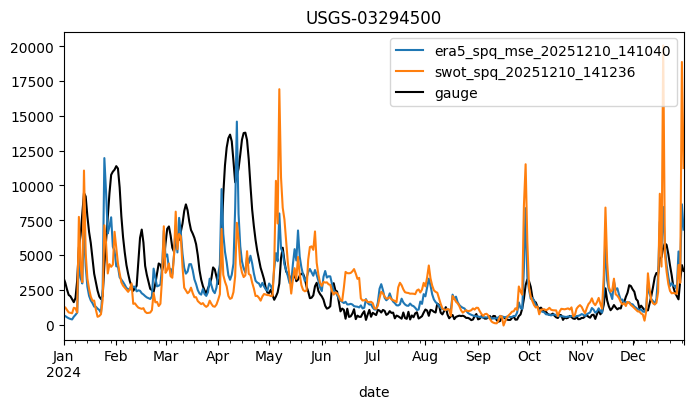

USGS-05355250
era5_spq_mse_20251210_141040: 0.28
swot_spq_20251210_141236: 0.58


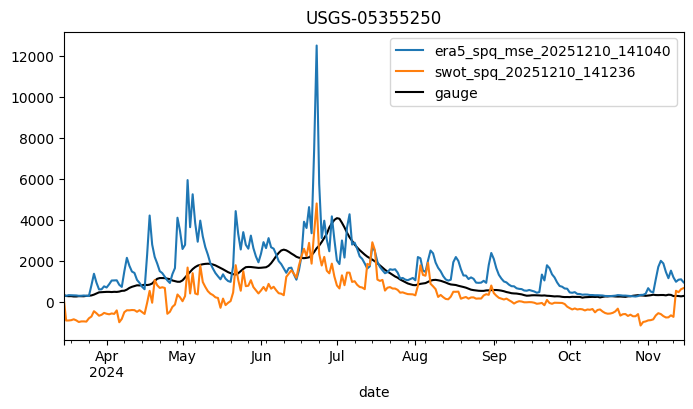

USGS-03292494
era5_spq_mse_20251210_141040: 0.51
swot_spq_20251210_141236: -1.83


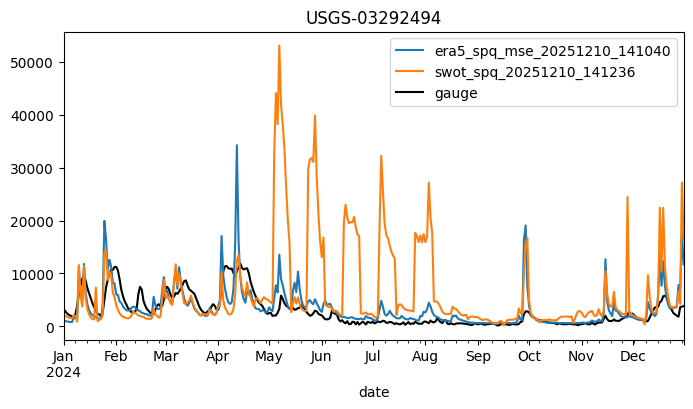

USGS-06185500
era5_spq_mse_20251210_141040: -0.77
swot_spq_20251210_141236: -2.93


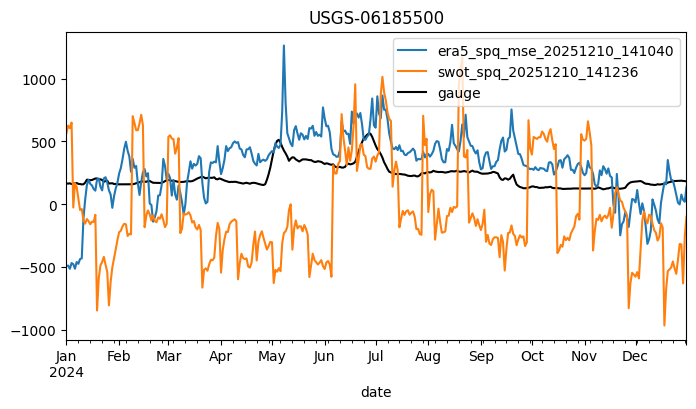

USGS-06324500
era5_spq_mse_20251210_141040: -2.42
swot_spq_20251210_141236: -2.45


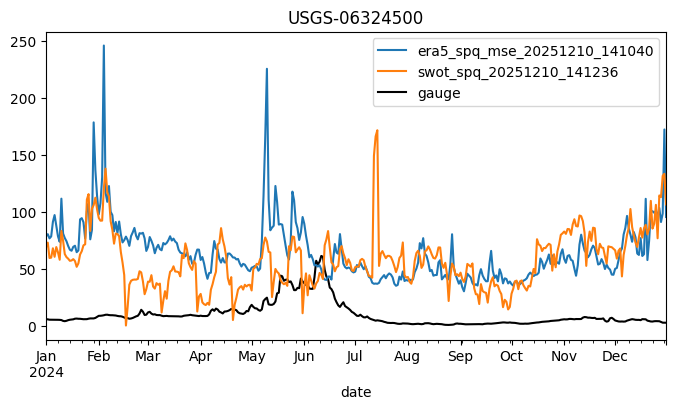

USGS-05344490
era5_spq_mse_20251210_141040: 0.42
swot_spq_20251210_141236: 0.34


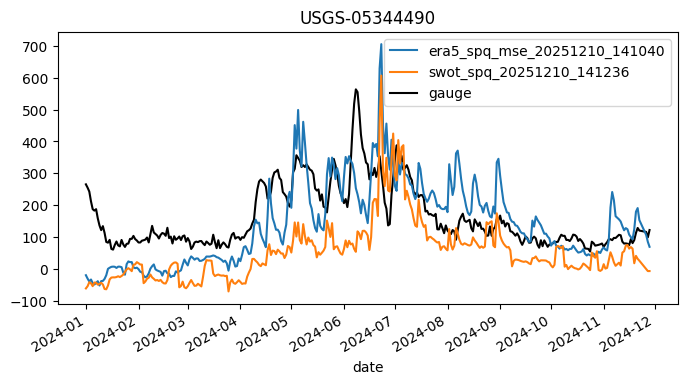

USGS-06801000
era5_spq_mse_20251210_141040: -8.57
swot_spq_20251210_141236: -13.51


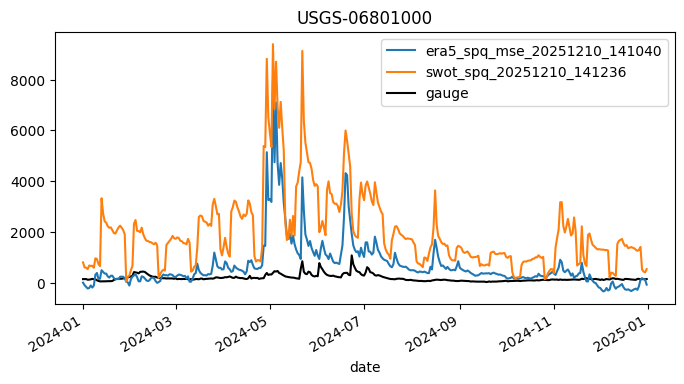

USGS-06207500
era5_spq_mse_20251210_141040: 0.60
swot_spq_20251210_141236: 0.36


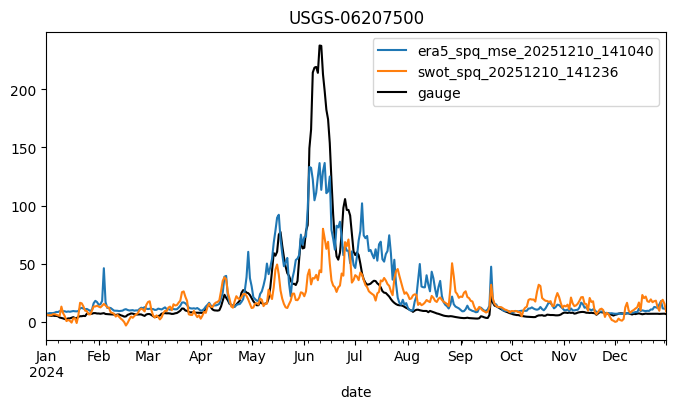

USGS-05385000
era5_spq_mse_20251210_141040: 0.50
swot_spq_20251210_141236: 0.46


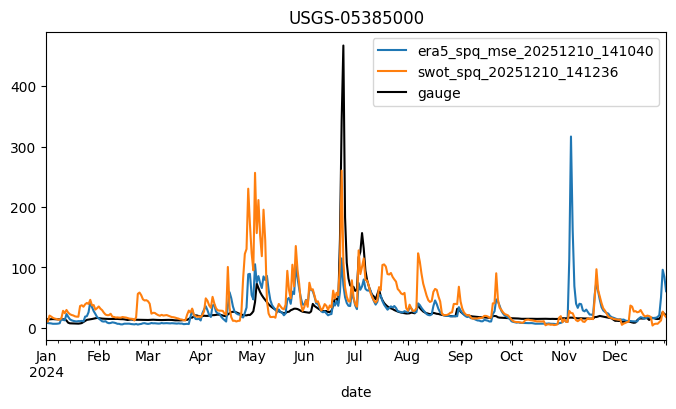

USGS-07260800
era5_spq_mse_20251210_141040: -6.26
swot_spq_20251210_141236: -11.26


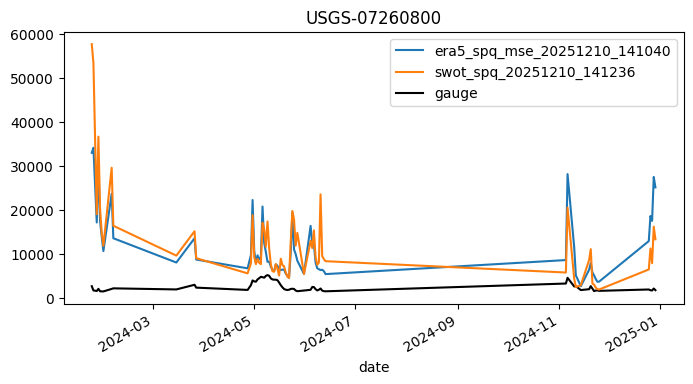

USGS-05344500
era5_spq_mse_20251210_141040: 0.75
swot_spq_20251210_141236: 0.57


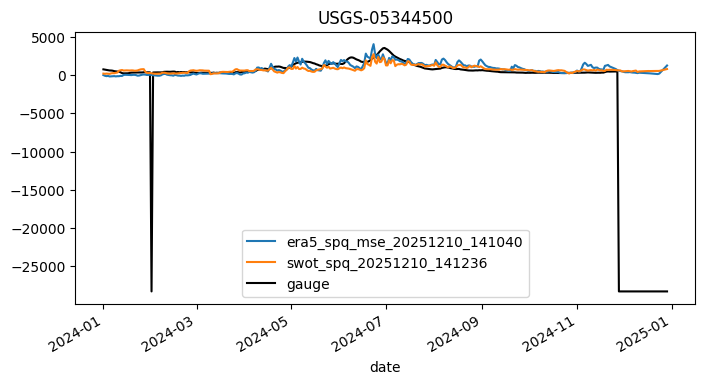

USGS-06770200
era5_spq_mse_20251210_141040: -20.80
swot_spq_20251210_141236: -23.49


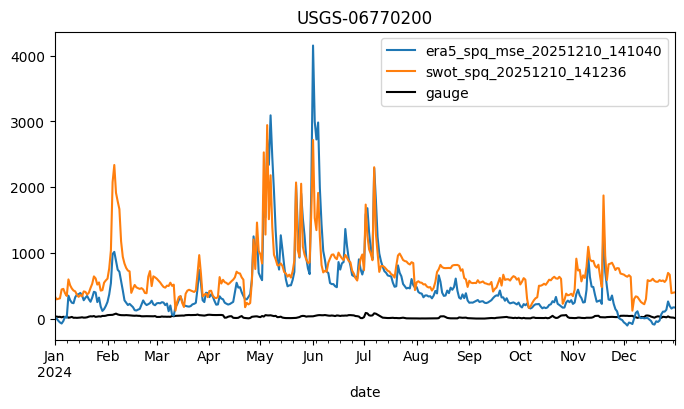

USGS-03185400
era5_spq_mse_20251210_141040: 0.50
swot_spq_20251210_141236: 0.29


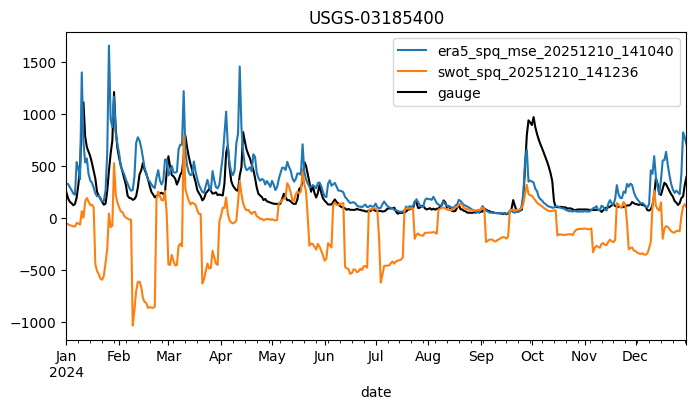

USGS-05270700
era5_spq_mse_20251210_141040: 0.80
swot_spq_20251210_141236: 0.70


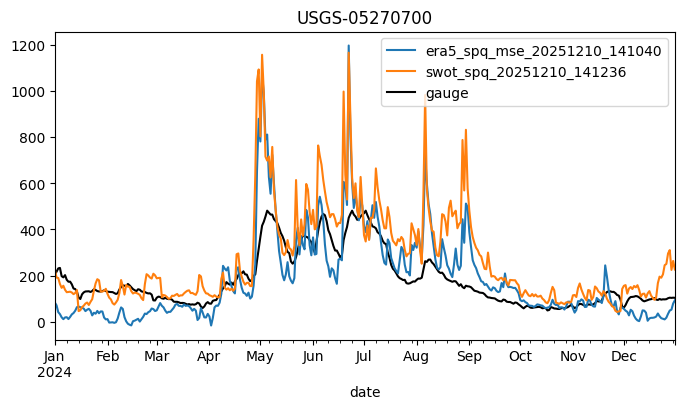

In [47]:
metric = 'KGE'
start_date = '2024-01-01'
end_date = '2024-12-31'
colors = ['tab:blue','tab:orange']

for reach_id in gauge_swot_count.iloc[:20].index:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))

    print(reach_id)

    for (exp_name, results, bulk_metrics, basin_metrics), color in zip(exps, colors): 
        x = results.xs(reach_id, level='subbasin').sort_index()
        x = x.droplevel(0,0)
        x = x.loc[start_date:end_date]
        x['pred'][target].plot(ax=ax, color = color, label=exp_name)
        print(f"{exp_name}: {basin_metrics.loc[reach_id][target][metric]:0.2f}")
        
    x['obs'][target].plot(color='black', ax=ax, zorder=0, label='gauge')
    plt.legend()
    plt.title(reach_id)
    plt.show()

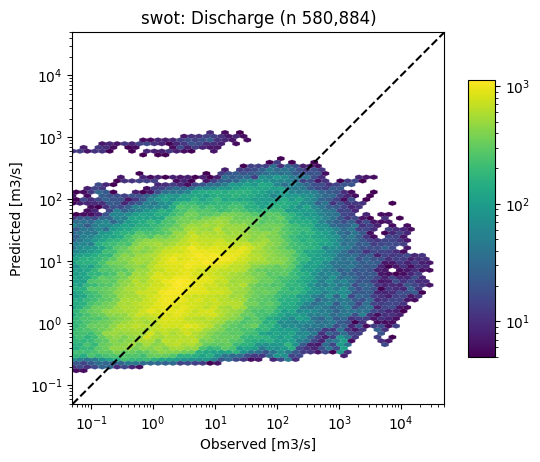

In [131]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

exp_idx = 1
name = exps[exp_idx][0]

x = exps[exp_idx][1]['obs'][target]
y = exps[exp_idx][1]['pred'][target]
positive_mask = (x > 0) & (y > 0)
x = x[positive_mask]
y = y[positive_mask]

min_val = 5E-2
max_val = 5E4
log_min = np.log10(min_val)
log_max = np.log10(max_val)

hb = ax.hexbin(x, y, gridsize=(50,50), bins='log', mincnt=5,
            linewidth=0.1,
            extent=(log_min, log_max, log_min, log_max),
            xscale='log', yscale='log')
plt.colorbar(hb, shrink=0.6, aspect=10, anchor=(0,0.5))

# Add a 1:1 line over the min and max of x and y
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5)

# Setting axes to be square and equal range
ax.axis('square')
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_title(f"{name}: Discharge (n {len(x):,})")
ax.set_xlabel(f'Observed [m3/s]')
ax.set_ylabel(f'Predicted [m3/s]')
plt.show()

# fig.savefig(fig_dir / f"{name}_bulk_scatterplots.png", dpi=300)